In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

# from mpl_toolkits.mplot3d import Axes3D

typestore = get_typestore(Stores.ROS2_HUMBLE)

In [3]:
bag_path = '/home/developer/ros2_ws/src/rosbag2_2026_05_26-16_55_17/rosbag2_2026_05_26-16_55_17_0.db3'
# '/home/developer/ros2_ws/src/rosbag2_2026_05_26-16_50_36/rosbag2_2026_05_26-16_50_36_0.db3' # <= best results
# '/home/developer/ros2_ws/src/rosbag2_2026_05_26-14_47_24/rosbag2_2026_05_26-14_47_24_0.db3'
# '/home/developer/ros2_ws/src/rosbag2_2026_05_26-14_01_17/elipse_1.db3' 


target_topic = '/crazyflie/ActualState'
trajectory_waypoints = '/home/developer/ros2_ws/src/trajectory/trajectory_examples/elipse.csv'

In [4]:


pose_list = []
velocity_list = []

with AnyReader([Path(bag_path)], default_typestore=typestore) as reader:
    # iterate over topics
    connections = [x for x in reader.connections if x.topic == target_topic]

    if not connections:
        print(f"Can't find topic: {target_topic} in selected rosbag.")
    
    # iterate over msgs
    for connection, timestamp, rawdata in reader.messages(connections=connections):
        msg = reader.deserialize(rawdata, connection.msgtype)
        if msg is not None:
            # pose - global 
            pose_i = np.array([msg.pose.pose.position.x, msg.pose.pose.position.y, msg.pose.pose.position.z])
            # velocity - local 
            vel_i = np.array([msg.twist.twist.linear.x, msg.twist.twist.linear.y, msg.twist.twist.linear.z])
            
            pose_list.append(pose_i)
            velocity_list.append(vel_i)
        

pose_np = np.array(pose_list)
velocity_np = np.array(velocity_list)

samples_num = pose_np.shape[0]

print(f'Recived {samples_num} samples.')


waypoints_df = pd.read_csv(trajectory_waypoints, skiprows=1)
waypoints_np = waypoints_df.values
print(f'Imported {waypoints_np.shape[0]} waypoints.')

Recived 1265 samples.
Imported 19 waypoints.


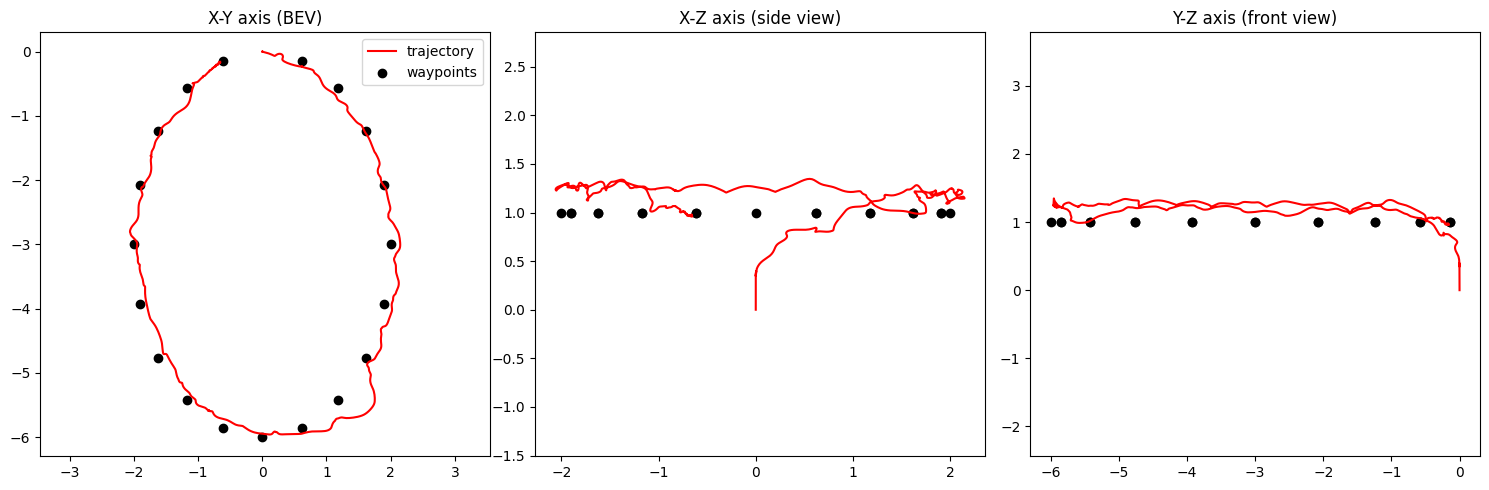

In [5]:
start = int(0 * samples_num)
end = int(1 * samples_num)

trajectory_x, trajectory_y, trajectory_z = pose_np[start:end, 0], pose_np[start:end, 1], pose_np[start:end, 2]
waypints_x, waypints_y, waypints_z = waypoints_np[:, 0], waypoints_np[:, 1], waypoints_np[:, 2]


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

#  (X - Y)
ax1.plot(trajectory_x, trajectory_y, color='red', label='trajectory')
ax1.scatter(waypints_x, waypints_y, color='black', label='waypoints')
ax1.set_title("X-Y axis (BEV)")
ax1.legend()
ax1.axis('equal') 

#  (X - Z)
ax2.plot(trajectory_x, trajectory_z, color='red')
ax2.scatter(waypints_x, waypints_z, color='black')
ax2.set_title("X-Z axis (side view)")
ax2.axis('equal')

#  (Y - Z)
ax3.plot(trajectory_y, trajectory_z, color='red')
ax3.scatter(waypints_y, waypints_z, color='black')
ax3.set_title("Y-Z axis (front view)")
ax3.axis('equal')

plt.tight_layout()
plt.show()

In [7]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=trajectory_x, 
    y=trajectory_y, 
    z=trajectory_z,
    mode='lines',
    name='Trajektoria drona',
    line=dict(color='blue', width=4)
))

fig.add_trace(go.Scatter3d(
    x=waypints_x, 
    y=waypints_y, 
    z=waypints_z,
    mode='markers',
    name='Waypointy',
    marker=dict(color='black', size=4)
))

fig.update_layout(
    title="Drone trajectory",
    scene=dict(
        xaxis_title=' X (m)',
        yaxis_title=' Y (m)',
        zaxis_title=' Z (m)'
    ),
    width=900,
    height=700
)

fig.show()